# Interpreting Financial NLP Models with SHAP

**Docker image**: `ml4t-gpu`

**Chapter 12: Gradient Boosting - Inside the Black Box**
**Section Reference**: See Section 12.5 for SHAP theory and methodology

## Purpose
This notebook demonstrates how to use SHAP (SHapley Additive exPlanations)
to interpret Transformer model predictions on financial text. Understanding
why a model makes specific predictions is essential for risk management,
debugging, and discovering new alpha signals.

## Learning Objectives
After completing this notebook, you will be able to:
- Apply SHAP to explain Transformer text classification predictions
- Interpret token-level feature attributions for sentiment analysis
- Identify which words drive positive vs negative predictions
- Understand the "net loss narrowed" paradox (context overrides keywords)
- Apply interpretability insights to model validation and alpha discovery

**Book Reference**: Chapter 12, Section 12.5 (SHAP beyond tabular data)

**Prerequisites**: Requires `transformers` and `shap` packages; downloads
FinBERT weights (~420 MB) on first run. GPU recommended but not required.

## Cross-References
- **Foundation**: Section 12.5 explains SHAP theory (Shapley values, additivity)
- **Related**: Chapter 10 covers text feature engineering and FinBERT
- **Application**: Extends SHAP from tabular features to text tokens

In [1]:
"""Interpreting Financial NLP Models with SHAP — apply SHAP to FinBERT for token-level sentiment attribution."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import torch  # isort:skip  # must be imported before shap (CUDA runtime conflict)
import shap
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: GPU


In [2]:
MAX_SENTENCES = 0  # 0 = all sentences

SEED = 42

In [3]:
set_global_seeds(SEED)

## Load Pre-trained FinBERT

We use FinBERT-tone which is already fine-tuned for financial sentiment.

In [4]:
# Load model and create pipeline
model_name = "yiyanghkust/finbert-tone"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None,
)

# Label mapping
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda:0


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

In [5]:
# Test the model
test_sentences = [
    "Revenue growth exceeded analyst expectations.",
    "The company announced significant layoffs.",
    "Net loss narrowed from the prior year.",
    "Guidance was raised for the fiscal year.",
    "Management expressed concerns about margin pressure.",
]

pred_rows = []
for text in test_sentences:
    result = classifier(text)[0]
    best = max(result, key=lambda x: x["score"])
    pred_rows.append(
        {"text": text[:50], "prediction": best["label"], "confidence": round(best["score"], 3)}
    )

pl.DataFrame(pred_rows)

text,prediction,confidence
str,str,f64
"""Revenue growth exceeded analyst expectations.""","""Positive""",1.0
"""The company announced significant layoffs.""","""Negative""",0.581
"""Net loss narrowed from the prior year.""","""Positive""",0.747
"""Guidance was raised for the fiscal year.""","""Positive""",1.0
"""Management expressed concerns about margin pressur""","""Negative""",1.0


## SHAP Explainer for Text Classification

SHAP explains predictions by computing the contribution of each token
to the final prediction. Positive SHAP values push toward a class,
negative values push away from it.

In [6]:
# Create SHAP explainer
# Use a wrapper function that returns probabilities


def predict_proba(texts):
    """Wrapper for SHAP compatibility."""
    results = []
    for text in texts:
        output = classifier(text)[0]
        # Sort by label order: Negative, Neutral, Positive
        probs = sorted(output, key=lambda x: x["label"])
        results.append([p["score"] for p in probs])
    return np.array(results)


# Create explainer with a small background dataset
background_texts = [
    "The company reported quarterly results.",
    "Shares were trading today.",
    "The CEO made a statement.",
]

print("Initializing SHAP explainer...")
explainer = shap.Explainer(
    predict_proba,
    tokenizer,
    output_names=["Negative", "Neutral", "Positive"],
)

Initializing SHAP explainer...


## Explaining Individual Predictions

Let's examine which words drove specific predictions.

In [7]:
# Sentences to explain
explain_sentences = [
    "Net loss narrowed significantly from the prior year.",
    "Revenue growth slowed amid weakening demand.",
    "The company raised its full-year guidance.",
]

shap_values = explainer(explain_sentences)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [8]:
# Top token contributions per sentence — render as a single DataFrame
top_rows = []
for i, text in enumerate(explain_sentences):
    result = classifier(text)[0]
    best = max(result, key=lambda x: x["score"])
    class_idx = {"Negative": 0, "Neutral": 1, "Positive": 2}[best["label"]]

    values = shap_values[i, :, class_idx].values
    tokens = shap_values[i].data

    contributions = [
        (tok, float(val))
        for tok, val in zip(tokens, values, strict=False)
        if tok not in ("[CLS]", "[SEP]", "[PAD]")
    ]
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    for token, value in contributions[:8]:
        top_rows.append(
            {
                "sentence": text,
                "predicted": best["label"],
                "confidence": round(best["score"], 3),
                "token": token,
                "shap_value": round(value, 4),
                "direction": "+" if value > 0 else "−",
            }
        )

token_attr_df = pl.DataFrame(top_rows)
token_attr_df

sentence,predicted,confidence,token,shap_value,direction
str,str,f64,str,f64,str
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""narrowed """,0.3726,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""Net """,0.2048,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""loss """,0.1839,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""from """,-0.1538,"""−"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""significantly """,0.0378,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,""".""",0.0218,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""the """,0.0169,"""+"""
"""Net loss narrowed significantly from the prior yea…","""Positive""",0.697,"""year""",0.0114,"""+"""
"""Revenue growth slowed amid weakening demand.""","""Negative""",1.0,"""slowed """,0.5328,"""+"""


In [9]:
# SHAP text plot for visualization
# This creates an HTML visualization of token attributions

for i, text in enumerate(explain_sentences):
    result = classifier(text)[0]
    best = max(result, key=lambda x: x["score"])
    class_idx = {"Negative": 0, "Neutral": 1, "Positive": 2}[best["label"]]

    print(f"\n--- {best['label']} prediction for: '{text[:40]}...'")

    # Simple text visualization
    values = shap_values[i, :, class_idx].values
    tokens = shap_values[i].data

    # Color tokens by contribution
    output = []
    for token, value in zip(tokens, values, strict=False):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        if value > 0.05:
            output.append(f"[+{token}]")
        elif value < -0.05:
            output.append(f"[-{token}]")
        else:
            output.append(token)

    print("Tokens: " + " ".join(output))
    print("Legend: [+token] = positive contribution, [-token] = negative")


--- Positive prediction for: 'Net loss narrowed significantly from the...'
Tokens:  [+Net ] [+loss ] [+narrowed ] significantly  [-from ] the  prior  year . 
Legend: [+token] = positive contribution, [-token] = negative

--- Negative prediction for: 'Revenue growth slowed amid weakening dem...'
Tokens:  Revenue  growth  [+slowed ] [-amid ] [+weakening ] [+demand] . 
Legend: [+token] = positive contribution, [-token] = negative

--- Positive prediction for: 'The company raised its full-year guidanc...'
Tokens:  The  [+company ] [+raised ] its  full - year  guidance . 
Legend: [+token] = positive contribution, [-token] = negative


## Case Study: "Net loss narrowed"

This phrase is a classic example of context-dependent sentiment.
A dictionary-based approach might flag "loss" as negative, but the
full phrase indicates improvement (positive). The token-level SHAP
table below shows that "narrowed" has the highest positive attribution
and "loss" itself pushes the prediction *toward* Positive — the model
reads "loss narrowed" as a unit rather than as the word "loss" in
isolation, which a dictionary approach cannot do.

In [10]:
# Detailed analysis of "net loss narrowed"
text = "Net loss narrowed significantly from the prior year."
result = classifier(text)[0]
best = max(result, key=lambda x: x["score"])

print(f"Text: {text}")
print(f"Prediction: {best['label']} ({best['score']:.1%})")

sv = explainer([text])
values = sv[0, :, 2].values  # Index 2 = Positive
tokens = sv[0].data

net_loss_df = pl.DataFrame(
    {
        "token": [t for t in tokens if t not in ("[CLS]", "[SEP]", "[PAD]")],
        "shap_value_positive": [
            round(float(v), 3)
            for t, v in zip(tokens, values, strict=False)
            if t not in ("[CLS]", "[SEP]", "[PAD]")
        ],
    }
)
net_loss_df

Text: Net loss narrowed significantly from the prior year.
Prediction: Positive (69.7%)


token,shap_value_positive
str,f64
"""""",0.0
"""Net """,0.205
"""loss """,0.184
"""narrowed """,0.373
"""significantly """,0.038
"""from """,-0.154
"""the """,0.017
"""prior """,0.001
"""year""",0.011


## Global Feature Importance

Beyond individual predictions, we can aggregate SHAP values across
many sentences to understand which words generally drive predictions.

In [11]:
# Aggregate analysis on more sentences
many_sentences = [
    "Revenue exceeded expectations.",
    "Profit margins improved significantly.",
    "The company beat analyst estimates.",
    "Earnings per share increased.",
    "Growth accelerated in Q4.",
    "Sales declined sharply.",
    "Losses mounted during the quarter.",
    "Margins contracted due to costs.",
    "Revenue missed forecasts.",
    "Guidance was lowered.",
]

print("Analyzing aggregate feature importance...")
many_shap = explainer(many_sentences)

# Aggregate positive attribution
positive_words = {}
negative_words = {}

for i in range(len(many_sentences)):
    for j in range(many_shap[i].values.shape[0]):
        token = many_shap[i].data[j]
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        # Sum contributions across all classes
        value = float(many_shap[i, j, 2].values)  # Positive class
        if token not in positive_words:
            positive_words[token] = 0
            negative_words[token] = 0

        if value > 0:
            positive_words[token] += value
        else:
            negative_words[token] += abs(value)

Analyzing aggregate feature importance...


In [12]:
sorted_pos = sorted(positive_words.items(), key=lambda x: x[1], reverse=True)[:10]
sorted_neg = sorted(negative_words.items(), key=lambda x: x[1], reverse=True)[:10]

global_attr_df = pl.DataFrame(
    {
        "rank": list(range(1, 11)),
        "word_pos": [w for w, _ in sorted_pos],
        "score_pos": [round(float(s), 3) for _, s in sorted_pos],
        "word_neg": [w for w, _ in sorted_neg],
        "score_neg": [round(float(s), 3) for _, s in sorted_neg],
    }
)
global_attr_df

rank,word_pos,score_pos,word_neg,score_neg
i64,str,f64,str,f64
1,"""beat """,1.0,"""declined """,0.225
2,"""increased""",0.972,"""during """,0.004
3,"""exceeded """,0.899,"""the """,0.003
4,"""improved """,0.892,"""contracted """,0.002
5,"""accelerated """,0.651,""".""",0.001
6,"""sharply""",0.224,"""due """,0.001
7,"""Growth """,0.181,"""Sales """,0.001
8,"""Q4""",0.154,"""Guidance """,0.001
9,"""expectations""",0.099,"""forecasts""",0.001


**Interpretation**: Words with high positive attribution (e.g., "exceeded",
"growth", "raised") align with financial improvement language. Words with
high negative attribution signal deterioration. The contextual nature of
these attributions — "narrowed" is positive when modifying "loss" — is what
separates Transformer-based models from dictionary approaches.

## Applications in Finance

### 1. Risk Management
- Validate model relies on sensible features, not spurious correlations
- Ensure no leakage of forbidden information (e.g., forward-looking data)
- Audit model behavior before production deployment

### 2. Model Debugging
- When model fails, SHAP reveals which tokens misled it
- Identify data quality issues (noise tokens, encoding errors)
- Guide retraining with cleaned data

### 3. Alpha Discovery
- Words that consistently drive predictions may indicate patterns
- Unexpected SHAP attributions → potential new signal hypotheses
- Quantify which linguistic features matter for returns

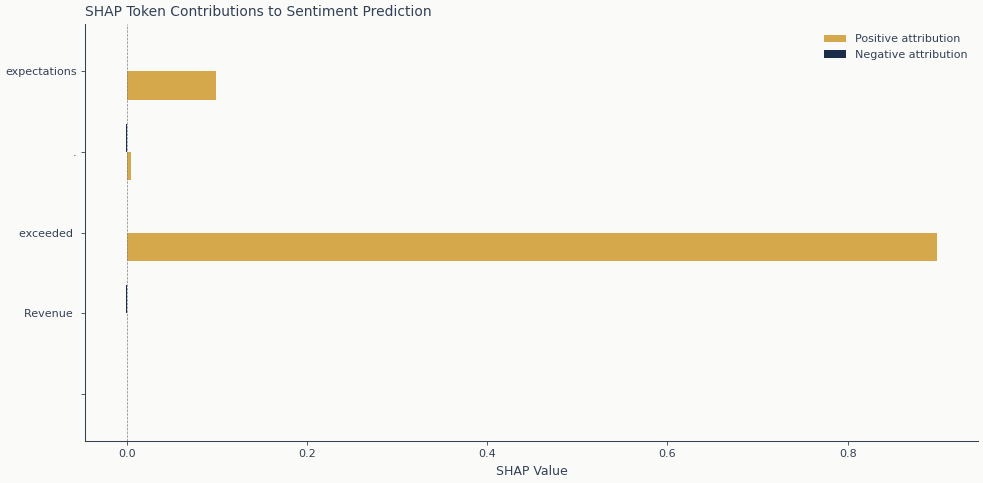

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

all_words = list(set(list(positive_words.keys())[:5] + list(negative_words.keys())[:5]))
pos_scores = [positive_words.get(w, 0) for w in all_words]
neg_scores = [-negative_words.get(w, 0) for w in all_words]

x = np.arange(len(all_words))
width = 0.35

ax.barh(x - width / 2, pos_scores, width, label="Positive attribution", color=COLORS["amber"])
ax.barh(x + width / 2, neg_scores, width, label="Negative attribution", color=COLORS["slate"])

ax.set_yticks(x)
ax.set_yticklabels(all_words)
ax.set_xlabel("SHAP Value")
ax.set_title("SHAP Token Contributions to Sentiment Prediction")
ax.legend()
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **SHAP** provides principled, theoretically-grounded feature attribution
   based on game-theoretic Shapley values.

2. **Token-level explanations** reveal how models understand context:
   "narrowed" outweighs "loss" in "net loss narrowed."

3. **Risk management** requires explainability: SHAP validates that models
   rely on sensible linguistic features, not spurious correlations.

4. **Alpha discovery**: Consistent SHAP patterns across many documents
   may reveal predictive linguistic features not obvious to analysts.

In [14]:
print("\nSHAP NLP sentiment notebook complete")


SHAP NLP sentiment notebook complete
